In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
from numba.core.errors import NumbaDeprecationWarning
warnings.simplefilter("ignore", category=NumbaDeprecationWarning)
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

In [3]:
import os
import sys
import numpy as np
import pandas as pd

In [4]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
sys.path.append("/home/chenxufeng/WorkSpace/scMagnify/src/")
from grn_tools import *
from grn_tools._stab_metrics import jaccard_similarity, cosine_similarity

## Configurations

In [6]:
# Set up matplotlib plot style
%matplotlib inline

plt.rcParams["figure.figsize"] = [4, 4]
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["image.cmap"] = "Spectral_r"
plt.rcParams["font.family"] = "Arial"
plt.rcParams['grid.alpha'] = 0
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams["text.usetex"] = False

In [7]:
fig_dir = "../figures/Fig2/" 
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
data_dir = "../data/Fig2/"
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

In [12]:
# algo_list=["GVAR_9", "Dictys", "FigR", "Pando", "CellOracle", "SCENIC", "Velorama", "GRNBoost2", "SINCERITITES"]
# algo_list=["GVAR_"+str(i) for i in experiments.keys()]

# algo_list=["scmagnify-"+str(i) for i in range(0, 10)]
# algo_list=["Dictys", "FigR", "Pando", "CellOracle", "SCENIC", "GRNBoost2", "SINCERITIES", "LINGER", "scmagnify-0"]

In [11]:
# datasets = {"PMID36973557_NatBiotechnol2023_CD34": ['Ery', 'Mono', 'CLP', 'Mega', 'cDC', 'pDC'],
#             "PMID36973557_NatBiotechnol2023_T-cell-depleted": ['Ery', 'Mono', 'NaiveB'],
#             "bioRxiv_Klein2023_Pancreas": ['Alpha', 'Beta', 'Delta', 'Epsilon']}

# datasets_lin = {"PMID36973557_NatBiotechnol2023_CD34":['240921',['Ery', 'Mono', 'CLP']],
#             "PMID36973557_NatBiotechnol2023_T-cell-depleted": ['240704', ['Ery', 'Mono', 'NaiveB']]}

# datasets_tissue = {"PMID36973557_NatBiotechnol2023_CD34":['240921',['Ery', 'Mono', 'CLP', 'cDC', 'pDC', 'Mega']],
#             "PMID36973557_NatBiotechnol2023_T-cell-depleted": ['240704', ['Ery', 'Mono', 'NaiveB']]}

datasets = {"PMID36973557_NatBiotechnol2023_T-cell-depleted": ['test2', ['Ery', 'Mono', 'NaiveB']]}

In [8]:
def load_nets_dict(algo_list, datasets, data_dir, q=0.1):
    
    nets_dict = {}
    
    ds_list = list(datasets.keys())
    for ds in ds_list:
        version = datasets[ds][0]
        lin_list = datasets[ds][1]
        grn_dir = data_dir + ds + "/benchmark/" + datasets[ds][0] + "/net/"
        
        for lin in lin_list:
            for algo in algo_list:
                edge_est = pd.read_csv(grn_dir + f"{algo}_{lin}.csv", index_col=None).reset_index(drop=True)
                edge_est.columns = ["TF", "Target", "Score"]
                # edge_est.Score = edge_est.Score.abs()
                edge_est.TF = edge_est.TF.str.upper()
                edge_est.Target = edge_est.Target.str.upper()
                # Just consider the positive values.
                edge_est = edge_est[edge_est.Score >= 0]
                
                # Quantile top 10% edges
                edge_est = edge_est.sort_values("Score", ascending=False)
                edge_est = edge_est.iloc[:int(edge_est.shape[0]*q)]
                
                nets_dict[f"{ds}#{lin}#{algo}"] = edge_est.TF + "_" + edge_est.Target
        
    return nets_dict

## Functions

In [9]:
def jaccard_similarity_net(nets_dict, col_name='link', figsize=(4, 4), title='jaccard Similarity', ax=None, fmt='.02f'):
    from itertools import combinations
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np
    # 1. Extract the source-target pairs from each network as a set of tuples
    nets_names = list(nets_dict.keys())
    nets = list(nets_dict.values())
    if col_name is None:
        link_sets = [set(net.values) for net in nets]
    else:
        link_sets = [set(net[col_name].unique()) for net in nets]
    # 2. Initialize an empty matrix for storing pairwise Jaccard similarities
    n = len(nets)
    jaccard_matrix = np.zeros((n, n))

    # 3. Compute the pairwise Jaccard similarity
    for i, j in combinations(range(n), 2):
        A = link_sets[i]
        B = link_sets[j]
        intersection = len(A.intersection(B))
        union = len(A.union(B))
        jaccard_similarity = intersection / union if union != 0 else 0
        jaccard_matrix[i, j] = jaccard_similarity
        jaccard_matrix[j, i] = jaccard_similarity
    # Fill diagonal with 1s (as similarity of a network with itself is 1)
    np.fill_diagonal(jaccard_matrix, np.NaN)
    # 4. Visualize the Jaccard matrix as a heatmap
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize)
    else:
        fig = None
    sns.heatmap(jaccard_matrix, annot=True, cmap="Spectral_r", xticklabels=nets_names, yticklabels=nets_names, ax=ax, fmt=fmt, cbar=None)
    ax.grid(False)
    ax.set_title(title)
    # Rotate x labels for readability
    plt.xticks(rotation=45, ha='right')

    return jaccard_matrix, fig

## Data-Driven reproducibility

### Random Seed

In [12]:
algo_list=["scmagnify-"+str(i) for i in range(0, 10)]
nets_dict = load_nets_dict(algo_list, datasets, "/home/chenxufeng/picb_cxf/Data/", q=0.1)

In [13]:
seed_nets_list = [key for key in nets_dict.keys() if key.split("#")[0] == "PMID36973557_NatBiotechnol2023_T-cell-depleted"]
seed_nets_dict = {key.split("#")[1]+"_"+key.split("#")[2]: nets_dict[key] for key in seed_nets_list}

In [14]:
seed_nets_dict.keys()

dict_keys(['Ery_scmagnify-0', 'Ery_scmagnify-1', 'Ery_scmagnify-2', 'Ery_scmagnify-3', 'Ery_scmagnify-4', 'Ery_scmagnify-5', 'Ery_scmagnify-6', 'Ery_scmagnify-7', 'Ery_scmagnify-8', 'Ery_scmagnify-9', 'Mono_scmagnify-0', 'Mono_scmagnify-1', 'Mono_scmagnify-2', 'Mono_scmagnify-3', 'Mono_scmagnify-4', 'Mono_scmagnify-5', 'Mono_scmagnify-6', 'Mono_scmagnify-7', 'Mono_scmagnify-8', 'Mono_scmagnify-9', 'NaiveB_scmagnify-0', 'NaiveB_scmagnify-1', 'NaiveB_scmagnify-2', 'NaiveB_scmagnify-3', 'NaiveB_scmagnify-4', 'NaiveB_scmagnify-5', 'NaiveB_scmagnify-6', 'NaiveB_scmagnify-7', 'NaiveB_scmagnify-8', 'NaiveB_scmagnify-9'])

In [15]:
seed_nets_dict["Ery_scmagnify-0"]

0           SP3_CENPF
1          JUNB_CENPP
2       BCL11A_DIAPH3
3            TCF3_WRN
4         FOXP1_CENPP
            ...      
3047      FLI1_CASC15
3048     SMAD3_CDKAL1
3049      LEF1_ZNF827
3050      MEF2A_LTBP1
3051       MITF_CEP83
Length: 3052, dtype: object

In [16]:
seed_nets_list

['PMID36973557_NatBiotechnol2023_T-cell-depleted#Ery#scmagnify-0',
 'PMID36973557_NatBiotechnol2023_T-cell-depleted#Ery#scmagnify-1',
 'PMID36973557_NatBiotechnol2023_T-cell-depleted#Ery#scmagnify-2',
 'PMID36973557_NatBiotechnol2023_T-cell-depleted#Ery#scmagnify-3',
 'PMID36973557_NatBiotechnol2023_T-cell-depleted#Ery#scmagnify-4',
 'PMID36973557_NatBiotechnol2023_T-cell-depleted#Ery#scmagnify-5',
 'PMID36973557_NatBiotechnol2023_T-cell-depleted#Ery#scmagnify-6',
 'PMID36973557_NatBiotechnol2023_T-cell-depleted#Ery#scmagnify-7',
 'PMID36973557_NatBiotechnol2023_T-cell-depleted#Ery#scmagnify-8',
 'PMID36973557_NatBiotechnol2023_T-cell-depleted#Ery#scmagnify-9',
 'PMID36973557_NatBiotechnol2023_T-cell-depleted#Mono#scmagnify-0',
 'PMID36973557_NatBiotechnol2023_T-cell-depleted#Mono#scmagnify-1',
 'PMID36973557_NatBiotechnol2023_T-cell-depleted#Mono#scmagnify-2',
 'PMID36973557_NatBiotechnol2023_T-cell-depleted#Mono#scmagnify-3',
 'PMID36973557_NatBiotechnol2023_T-cell-depleted#Mono#scma

2025-10-09 13:40:16 | [INFO] maxp pruned
2025-10-09 13:40:16 | [INFO] LTSH dropped
2025-10-09 13:40:16 | [INFO] cmap pruned
2025-10-09 13:40:16 | [INFO] kern pruned
2025-10-09 13:40:16 | [INFO] post pruned
2025-10-09 13:40:16 | [INFO] PCLT dropped
2025-10-09 13:40:16 | [INFO] DSIG dropped
2025-10-09 13:40:16 | [INFO] glyf pruned
2025-10-09 13:40:16 | [INFO] Added gid0 to subset
2025-10-09 13:40:16 | [INFO] Added first four glyphs to subset
2025-10-09 13:40:16 | [INFO] Closing glyph list over 'glyf': 39 glyphs before
2025-10-09 13:40:16 | [INFO] Glyph names: ['.notdef', '.null', 'B', 'E', 'J', 'M', 'N', 'S', 'a', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'hyphen', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'underscore', 'v', 'y', 'zero']
2025-10-09 13:40:16 | [INFO] Glyph IDs:   [0, 1, 2, 3, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 37, 40, 45, 48, 49, 54, 66, 68, 70, 71, 72, 73, 74, 76, 79,

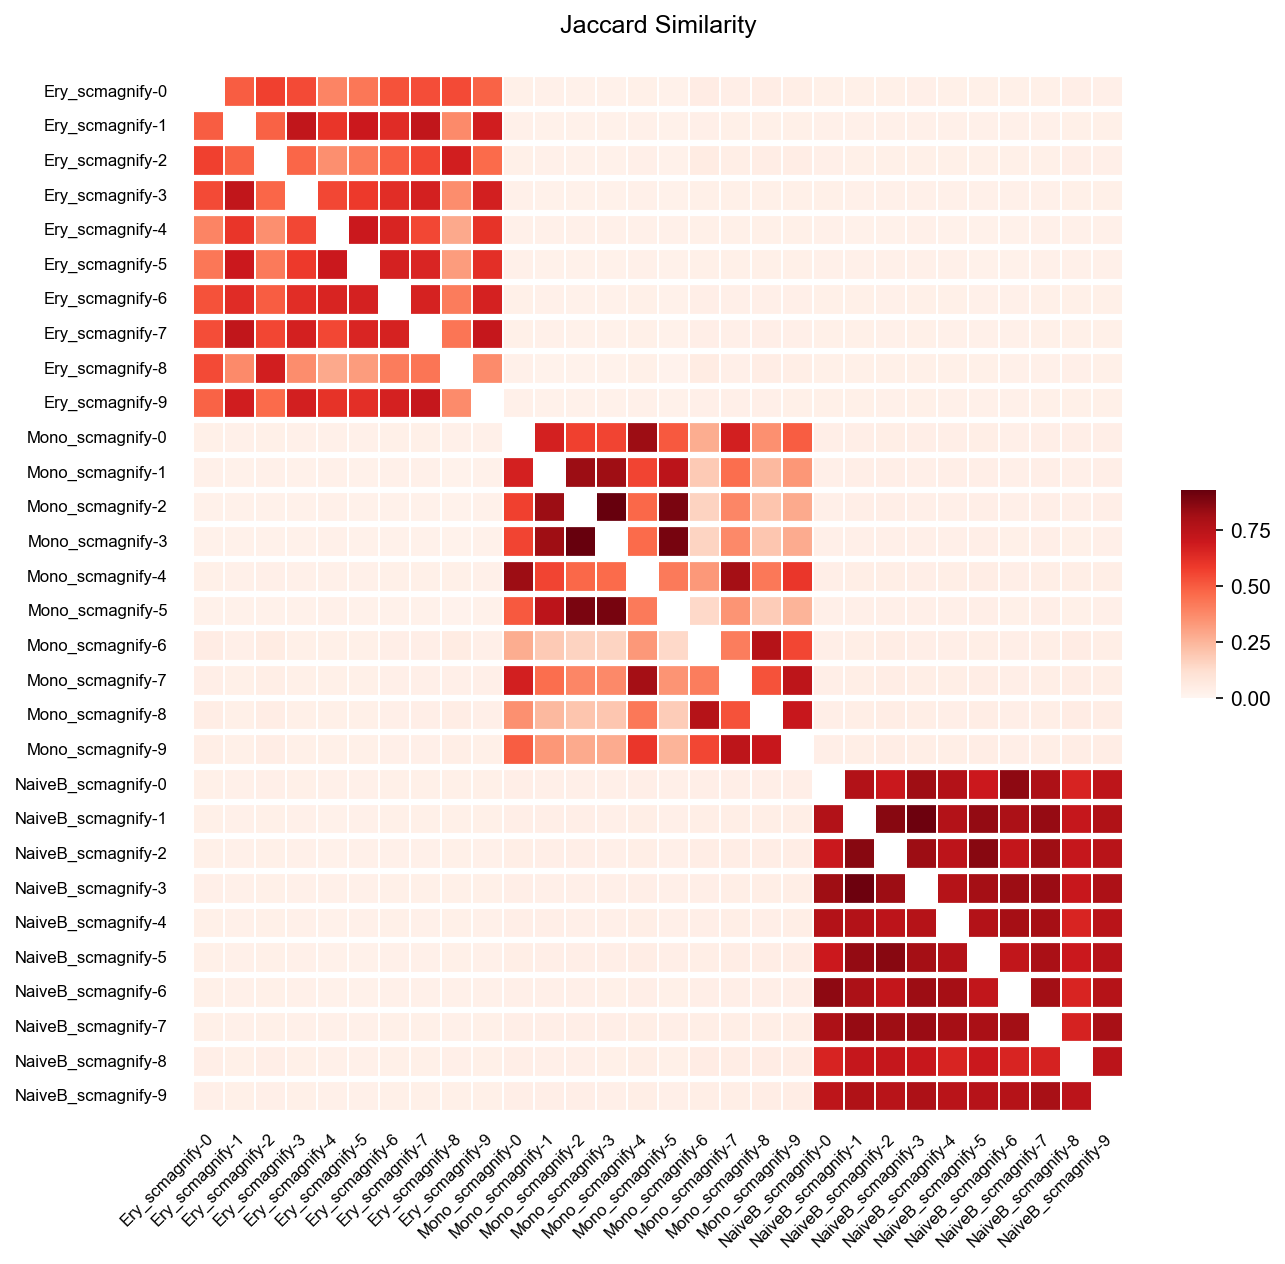

In [17]:
jaccard_mat = jaccard_similarity(seed_nets_dict, 
               labelsize=8, 
               annot=False, 
               figsize=(10, 9),
               save=os.path.join(fig_dir, "Fig2g-Jaccard_Similarity_tcell.pdf"))

## Save the data

In [24]:
jaccard_df = pd.DataFrame(jaccard_mat[0], index=seed_nets_dict.keys(), columns=seed_nets_dict.keys())
jaccard_df.to_csv(os.path.join(data_dir, "Fig2g-Jaccard_Similarity_tcell.csv"))

In [26]:
output_xlsx = os.path.join(data_dir, "SourceDataFig2g.xlsx")
with pd.ExcelWriter(output_xlsx, engine='xlsxwriter') as writer:
    jaccard_df.to_excel(writer, sheet_name='Fig2g')


2025-09-28 21:26:22 | [INFO] maxp pruned
2025-09-28 21:26:22 | [INFO] LTSH dropped
2025-09-28 21:26:22 | [INFO] cmap pruned
2025-09-28 21:26:22 | [INFO] kern pruned
2025-09-28 21:26:22 | [INFO] post pruned
2025-09-28 21:26:22 | [INFO] PCLT dropped
2025-09-28 21:26:22 | [INFO] DSIG dropped
2025-09-28 21:26:22 | [INFO] glyf pruned
2025-09-28 21:26:22 | [INFO] Added gid0 to subset
2025-09-28 21:26:22 | [INFO] Added first four glyphs to subset
2025-09-28 21:26:22 | [INFO] Closing glyph list over 'glyf': 38 glyphs before
2025-09-28 21:26:22 | [INFO] Glyph names: ['.notdef', '.null', 'B', 'C', 'E', 'M', 'N', 'S', 'a', 'c', 'e', 'eight', 'f', 'five', 'four', 'g', 'hyphen', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'underscore', 'v', 'y', 'zero']
2025-09-28 21:26:22 | [INFO] Glyph IDs:   [0, 1, 2, 3, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 37, 38, 40, 48, 49, 54, 66, 68, 70, 72, 73, 74, 76, 79, 80, 81, 

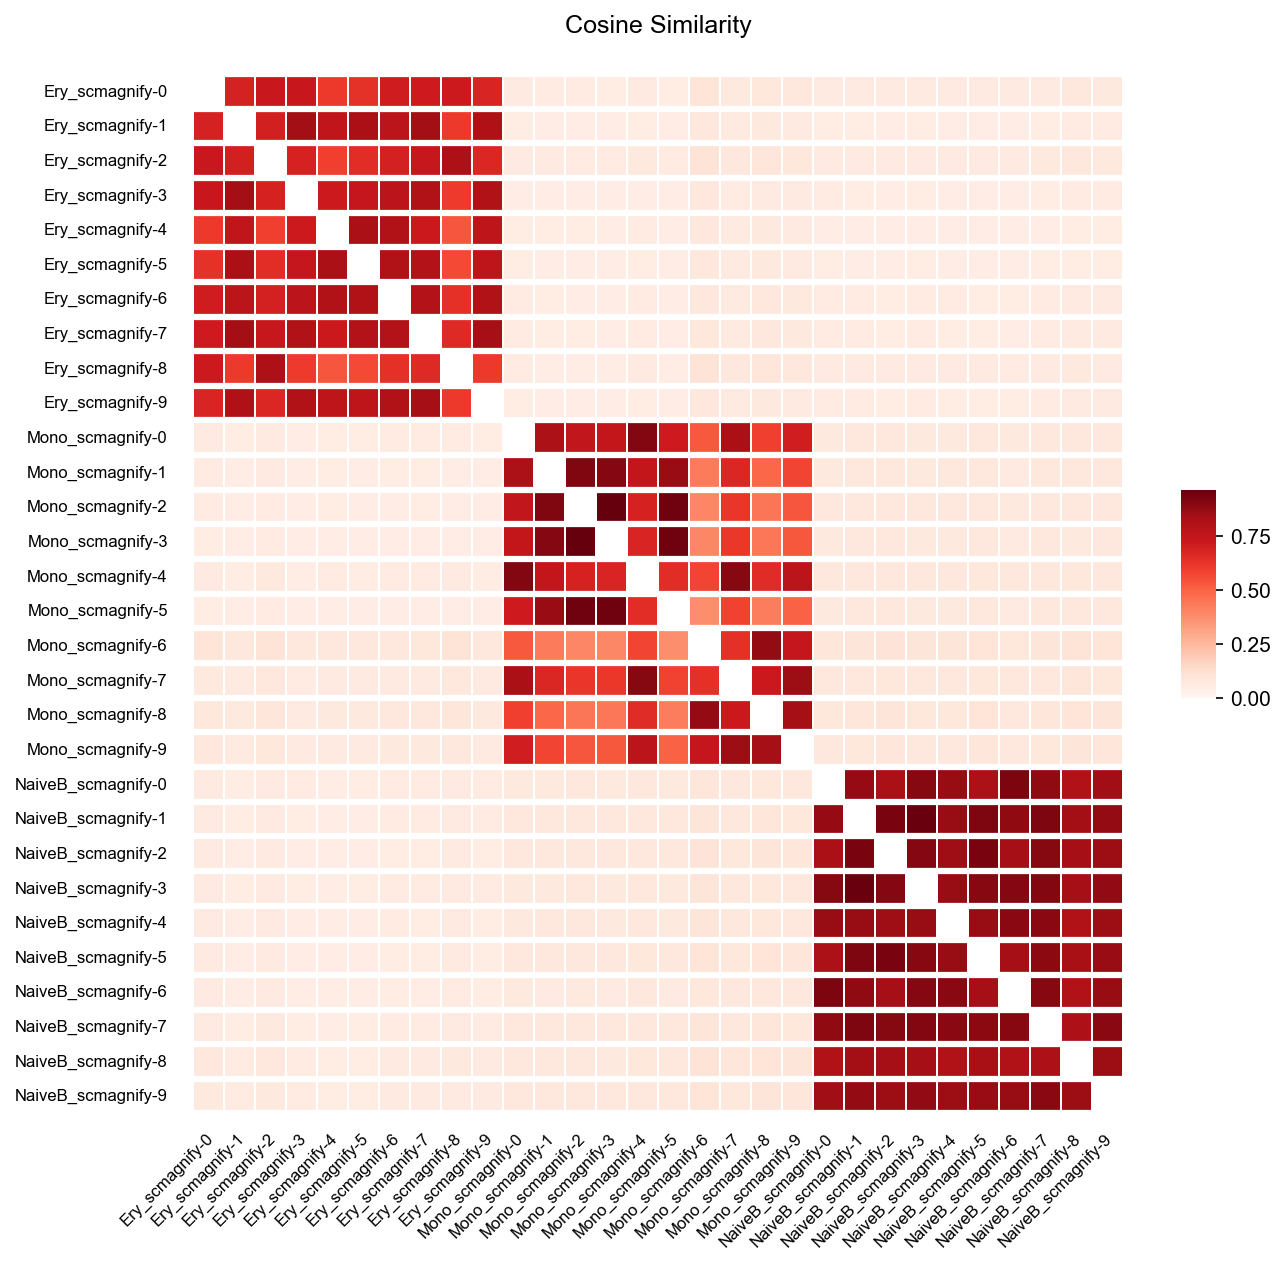

In [32]:
cosine_mat = cosine_similarity(seed_nets_dict, 
                  labelsize=8, 
                  annot=False, 
                  figsize=(10, 9),
                  save=os.path.join(fig_dir, "Cosine_Similarity_tcell.pdf"))

### DownSampled Cell

In [58]:
algo_list=["scmagnify-0"] + [f"scmagnify-{i}" for i in range(11, 20)] 

In [59]:
algo_list

['scmagnify-0',
 'scmagnify-11',
 'scmagnify-12',
 'scmagnify-13',
 'scmagnify-14',
 'scmagnify-15',
 'scmagnify-16',
 'scmagnify-17',
 'scmagnify-18',
 'scmagnify-19']

In [60]:
nets_dict = load_nets_dict(algo_list, datasets, data_dir, q=0.1)

In [61]:
down_nets_list = [key for key in nets_dict.keys() if key.split("#")[0] == "PMID36973557_NatBiotechnol2023_T-cell-depleted"]
down_nets_dict = {key.split("#")[1]+"_"+key.split("#")[2]: nets_dict[key] for key in down_nets_list}

(30, 30)
30


(array([[       nan, 0.50443999, 0.4408513 , 0.36031191, 0.32796997,
         0.26484338, 0.24732536, 0.13215859, 0.09240058, 0.09240058,
         0.03050546, 0.03532397, 0.02638651, 0.02374406, 0.02945174,
         0.03527981, 0.04508553, 0.03437565, 0.02866371, 0.02866371,
         0.03235613, 0.03755962, 0.03689395, 0.0352127 , 0.03070452,
         0.03174294, 0.03045886, 0.03087683, 0.02694163, 0.02694163],
        [0.50443999,        nan, 0.43077428, 0.35885013, 0.33768352,
         0.25557698, 0.23971769, 0.11361527, 0.08306756, 0.08306756,
         0.03141218, 0.03365831, 0.02761583, 0.02431323, 0.03099693,
         0.03453307, 0.04144823, 0.036009  , 0.03134872, 0.03134872,
         0.02819499, 0.03188474, 0.03317319, 0.03117389, 0.03001781,
         0.02821462, 0.02952988, 0.02731051, 0.02444188, 0.02444188],
        [0.4408513 , 0.43077428,        nan, 0.33847142, 0.32366362,
         0.25173082, 0.22753764, 0.11227883, 0.08086097, 0.08086097,
         0.03146564, 0.0339658 ,

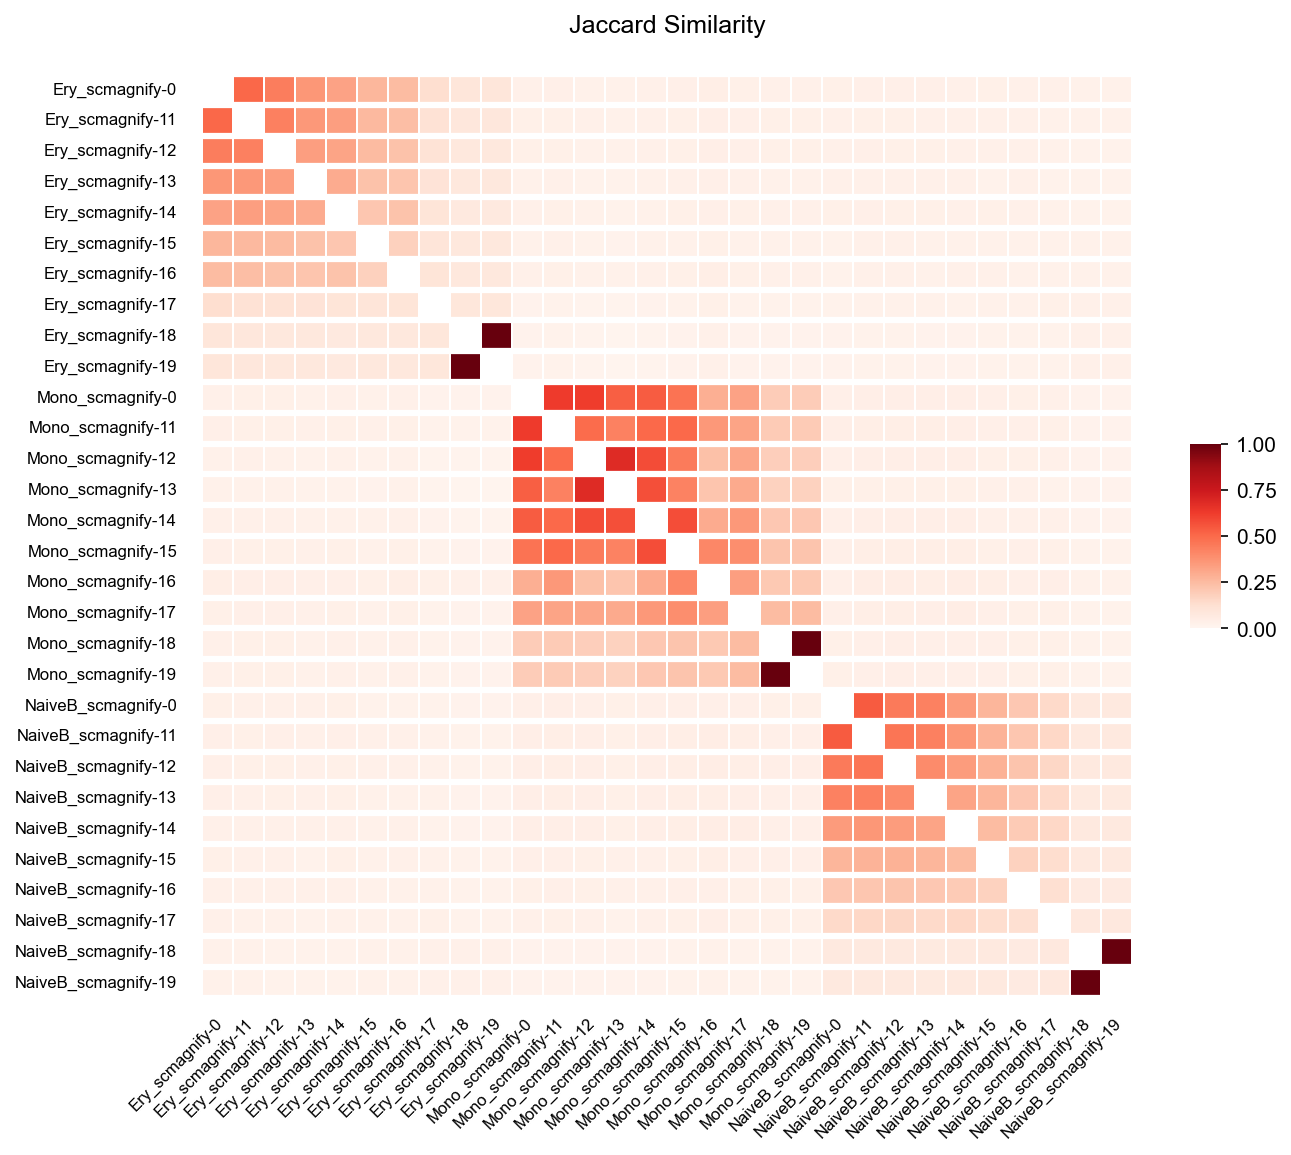

In [62]:
jaccard_similarity(down_nets_dict, 
                   labelsize=8, 
                   annot=False, 
                   figsize=(10, 8), 
                   save=os.path.join(fig_dir, "downsample_jaccard_250216.pdf"))

In [76]:
metrics_df = batch_evaluate_TFbind(algo_list=algo_list,
                      datasets=datasets,
                      mode="custom",
                      plot=False)

Output()

In [77]:
metrics_df.head()

,Algorithm,Dataset,Lineage,Nums_TF,Nums_Target,Precsions,Recalls,AUPR,AUPR Ratio1,AUPR Ratio2,EPR,FPRs,TPRs,AUROC,Confusion Matrix,Precision,Recall,F1 Score(topk),F0.1 Score(topk)
0,scmagnify-0,PMID36973557_NatBiotechnol2023_T-cell-depleted,Ery,30,1464,"[0.0, 0.0, 0.00032848813336618213, 0.000328488...","[0.0, 0.00013317352510320947, 0.00013317352510...",0.187450,1.099384,1.093282,1.292895,"[0.1705040871934605, 0.2139979387238827, 0.213...","[1.0, 0.30416833133573046, 0.30403515781062723...",0.539148,"[[30679, 5852], [5853, 1656]]",0.220565,0.220535,0.220550,0.220564
1,scmagnify-11,PMID36973557_NatBiotechnol2023_T-cell-depleted,Ery,30,1464,"[0.0, 0.0, 5.4748022227697024e-05, 5.474802222...","[0.0, 0.00013317352510320947, 0.00013317352510...",0.183755,1.077717,1.088813,1.281184,"[0.1705040871934605, 0.2173473258313314, 0.217...","[1.0, 0.2289252896524171, 0.2287921161273139, ...",0.530719,"[[30664, 5867], [5868, 1641]]",0.218567,0.218538,0.218552,0.218567
2,scmagnify-12,PMID36973557_NatBiotechnol2023_T-cell-depleted,Ery,30,1463,"[0.0, 0.0, 0.0003835406279107994, 0.0003835406...","[0.0, 0.00013319126265316994, 0.00013319126265...",0.182113,1.067499,1.066749,1.246314,"[0.17059759145648717, 0.21203512396694216, 0.2...","[1.0, 0.21870005327650507, 0.21870005327650507...",0.526475,"[[30592, 5910], [5911, 1597]]",0.212735,0.212706,0.212721,0.212735
3,scmagnify-13,PMID36973557_NatBiotechnol2023_T-cell-depleted,Ery,30,1464,"[0.0, 0.0, 2.7374011113848512e-05, 2.737401111...","[0.0, 0.00013317352510320947, 0.00013317352510...",0.179772,1.054355,1.059926,1.197645,"[0.1705040871934605, 0.2091218515997277, 0.209...","[1.0, 0.20455453455852976, 0.20455453455852976...",0.523143,"[[30722, 5809], [5973, 1536]]",0.209122,0.204555,0.206813,0.209076
4,scmagnify-14,PMID36973557_NatBiotechnol2023_T-cell-depleted,Ery,30,1463,"[0.0, 2.739500862942772e-05, 5.479001725885544...","[0.0, 0.0, 0.0, 0.0001332090049287332, 0.00013...",0.182824,1.071813,1.073376,1.169365,"[0.1705748693478755, 0.2212715739784629, 0.221...","[1.0, 0.19981350739309978, 0.19981350739309978...",0.528136,"[[31224, 5279], [6007, 1500]]",0.221272,0.199814,0.209996,0.221037


In [91]:
metrics_df["Algorithm"] = metrics_df["Algorithm"].replace({
    "scmagnify-0": "100%",
    "scmagnify-11": "90%",
    "scmagnify-12": "80%",
    "scmagnify-13": "70%",
    "scmagnify-14": "60%",
    "scmagnify-15": "50%",
    "scmagnify-16": "40%",
    "scmagnify-17": "30%",
    "scmagnify-18": "20%",
    "scmagnify-19": "10%",  
})

In [92]:
metrics_df["Algorithm"] = pd.Categorical(metrics_df["Algorithm"], 
                                               categories=["100%", "90%", "80%", "70%", "60%", "50%", "40%", "30%", "20%", "10%"], 
                                               ordered=True)

In [96]:
algo_palette = dict(zip(metrics_df["Algorithm"].cat.categories, sns.color_palette("tab10", 10)))
algo_palette

{'100%': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 '90%': (1.0, 0.4980392156862745, 0.054901960784313725),
 '80%': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 '70%': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 '60%': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 '50%': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 '40%': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 '30%': (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 '20%': (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 '10%': (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)}

<Axes: xlabel='AUPR', ylabel='F0.1 Score(topk)'>

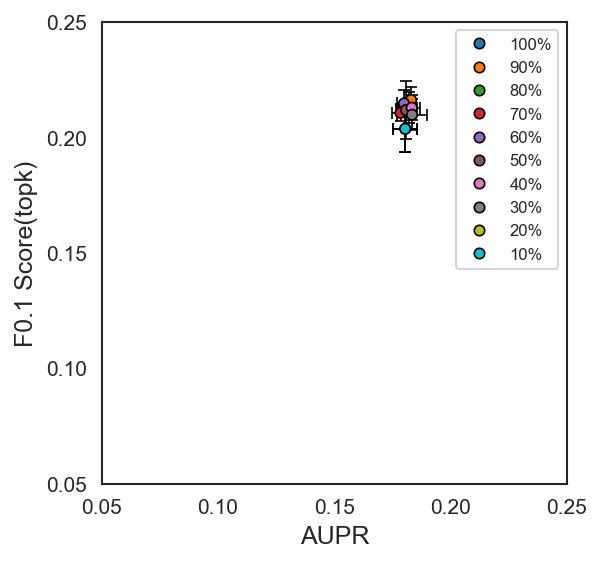

In [97]:
plot_scatter_with_error_bars(metrics_df, 
                             x_metric = "AUPR", 
                             y_metric = "F0.1 Score(topk)",
                             spline_linewidth=1,
                             palette=algo_palette,
                             xlim=[0.05, 0.25],
                             ylim=[0.05, 0.25],)

In [108]:
from grn_tools._plotting import plot_line

<Axes: xlabel='Algorithm', ylabel='AUPR'>

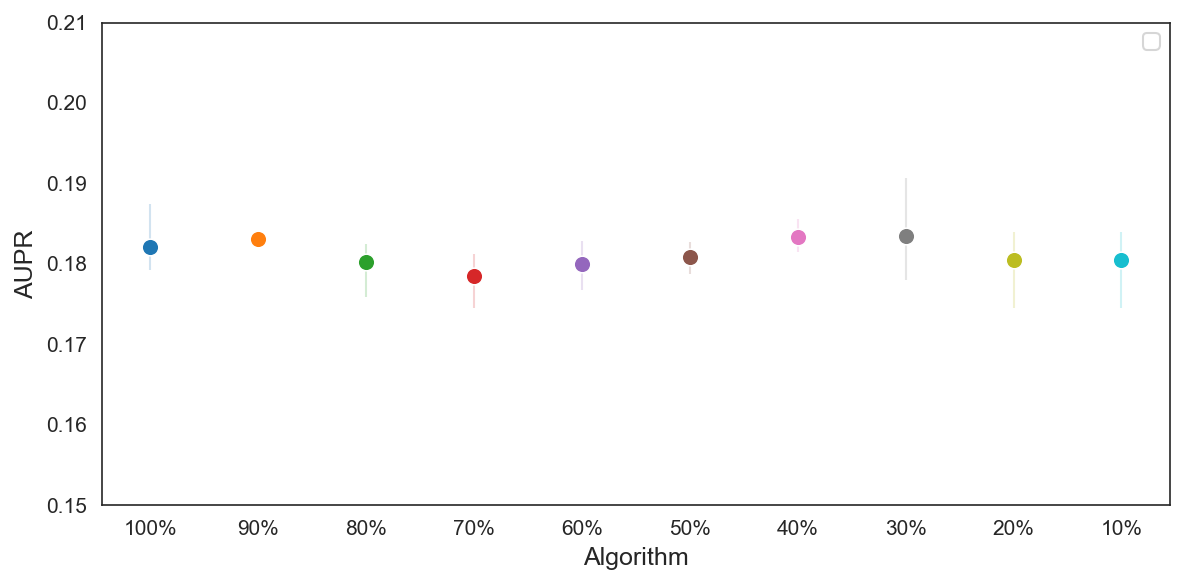

In [130]:
plot_line(metrics_df,
        x = "Algorithm",
        y = "AUPR",
        figsize = (8, 4),
        palette=algo_palette, 
        ylim=[0.15, 0.21],
        save=os.path.join(fig_dir, "downsample_AUPR_250216.pdf"))
        

<Axes: xlabel='Algorithm', ylabel='F0.1 Score(topk)'>

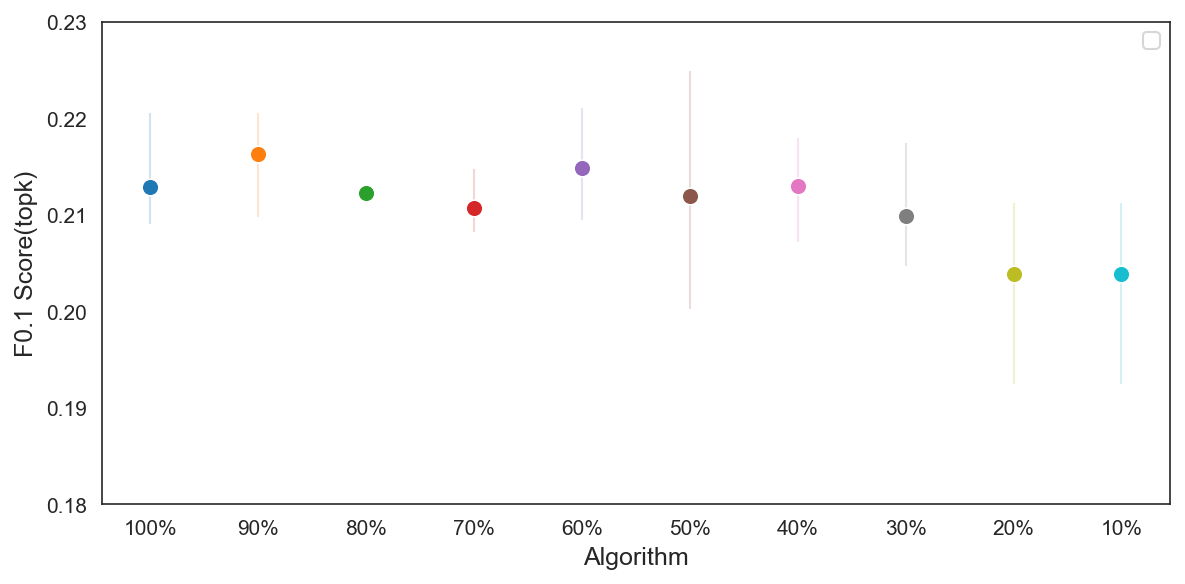

In [133]:
plot_line(metrics_df,
        x = "Algorithm",
        y = "F0.1 Score(topk)",
        figsize = (8, 4),
        palette=algo_palette, 
        ylim=[0.18, 0.23],
        save=os.path.join(fig_dir, "downsample_F0.1_250216.pdf"))

<Axes: >

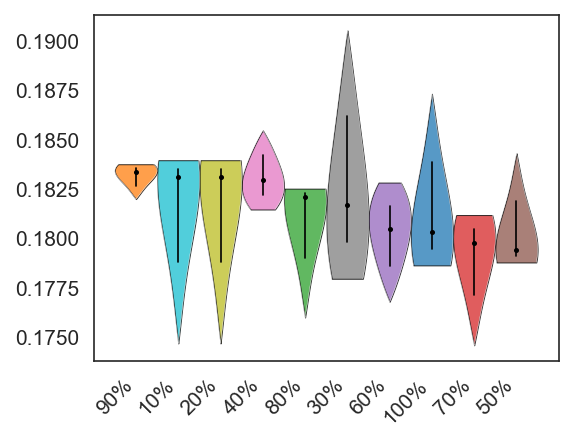

In [98]:
plot_violin(metrics_df, 
            x="Algorithm", 
            y="AUPR", 
            figsize=(8, 4), 
            spline_linewidth=0.8, 
            palette=algo_palette)

<Axes: >

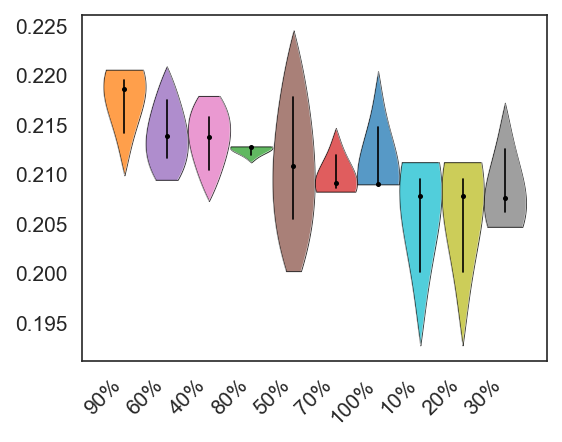

In [101]:
plot_violin(metrics_df, x="Algorithm", y="F0.1 Score(topk)", figsize=(8, 4), spline_linewidth=0.8, palette=algo_palette)